In [1]:
from pathlib import Path
import numpy as np
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd
%matplotlib inline

CAPSULA_DIR = Path("data/Capsula")

# Solo los ARD_ (sin Prueba)
STL_FILES = sorted(p for p in CAPSULA_DIR.glob("ARD_*.stl"))
print("Archivos encontrados:")
for p in STL_FILES:
    print(f"  {p.name}")

Archivos encontrados:
  ARD_chillfine.stl
  ARD_coarse.stl
  ARD_coarsest.stl
  ARD_fine.stl
  ARD_ultrafine.stl


In [4]:
# Carga todos y calcula propiedades
def load_stl_props(path):
    m      = trimesh.load(str(path), force="mesh")
    verts  = np.asarray(m.vertices, dtype=float)
    faces  = np.asarray(m.faces,    dtype=int)
    v0, v1, v2 = verts[faces[:,0]], verts[faces[:,1]], verts[faces[:,2]]
    cross  = np.cross(v1-v0, v2-v0)
    areas  = np.linalg.norm(cross, axis=1) / 2.0
    ext    = verts.max(0) - verts.min(0)
    return {
        "mesh":       m,
        "verts":      verts,
        "faces":      faces,
        "areas":      areas,
        "extents":    ext,
        "bmin":       verts.min(0),
        "bmax":       verts.max(0),
    }

data = {p.stem: load_stl_props(p) for p in STL_FILES}
print("Cargados:", list(data.keys()))

Cargados: ['ARD_chillfine', 'ARD_coarse', 'ARD_coarsest', 'ARD_fine', 'ARD_ultrafine']


In [5]:
# Tabla comparativa
rows = []
for name, d in data.items():
    ext = d["extents"]
    rows.append({
        "Archivo":          name,
        "Triángulos":       f"{len(d['faces']):,}",
        "Vértices":         f"{len(d['verts']):,}",
        "Ext. X (mm)":      f"{ext[0]:.2f}",
        "Ext. Y (mm)":      f"{ext[1]:.2f}",
        "Ext. Z (mm)":      f"{ext[2]:.2f}",
        "Área total (mm²)": f"{d['areas'].sum():.1f}",
        "S_ref (mm²)":      f"{ext[0]*ext[2]:.1f}",
        "L_ref (mm)":       f"{ext[1]:.2f}",
        "Cerrada":          "Sí" if d["mesh"].is_watertight else "No",
    })

df = pd.DataFrame(rows)
df.style.set_properties(**{"text-align": "left"}).hide(axis="index")

Archivo,Triángulos,Vértices,Ext. X (mm),Ext. Y (mm),Ext. Z (mm),Área total (mm²),S_ref (mm²),L_ref (mm),Cerrada
ARD_chillfine,"9,788","4,896",2800.00,2040.04,2800.00,18509731.5,7839975.4,2040.04,Sí
ARD_coarse,"1,438",721,2787.01,2040.04,2778.62,18370134.7,7744063.1,2040.04,Sí
ARD_coarsest,194,99,2739.79,2040.04,2764.87,17709349.1,7575161.6,2040.04,Sí
ARD_fine,"134,124","67,064",2799.99,2040.04,2799.90,18553007.9,7839676.0,2040.04,Sí
ARD_ultrafine,"350,794","175,399",2800.00,2040.04,2800.00,18557840.8,7839976.8,2040.04,Sí


  Guardado: results\Plots\Mallados\ARD_chillfine.png


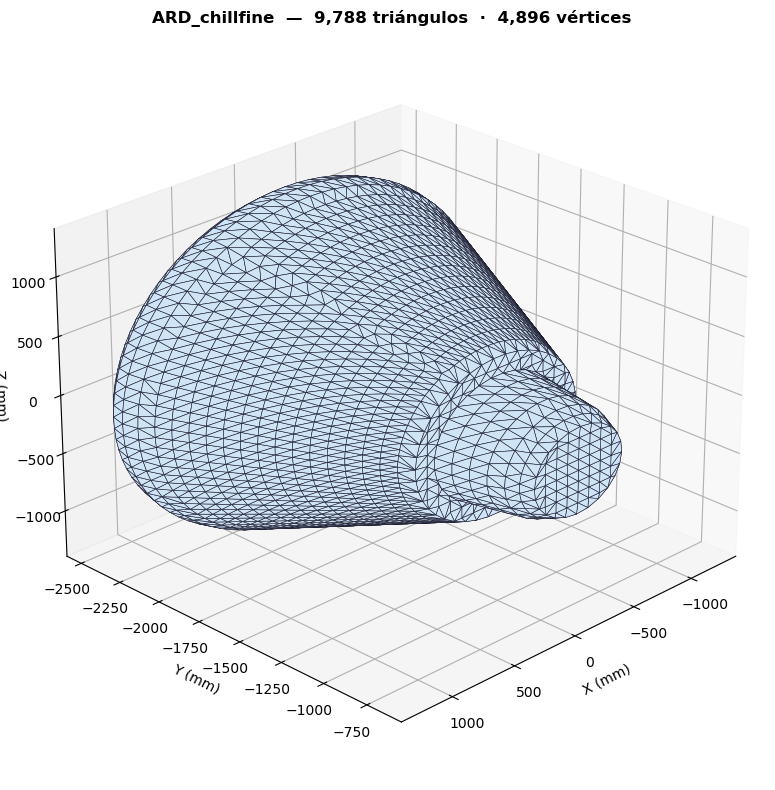

  Guardado: results\Plots\Mallados\ARD_coarse.png


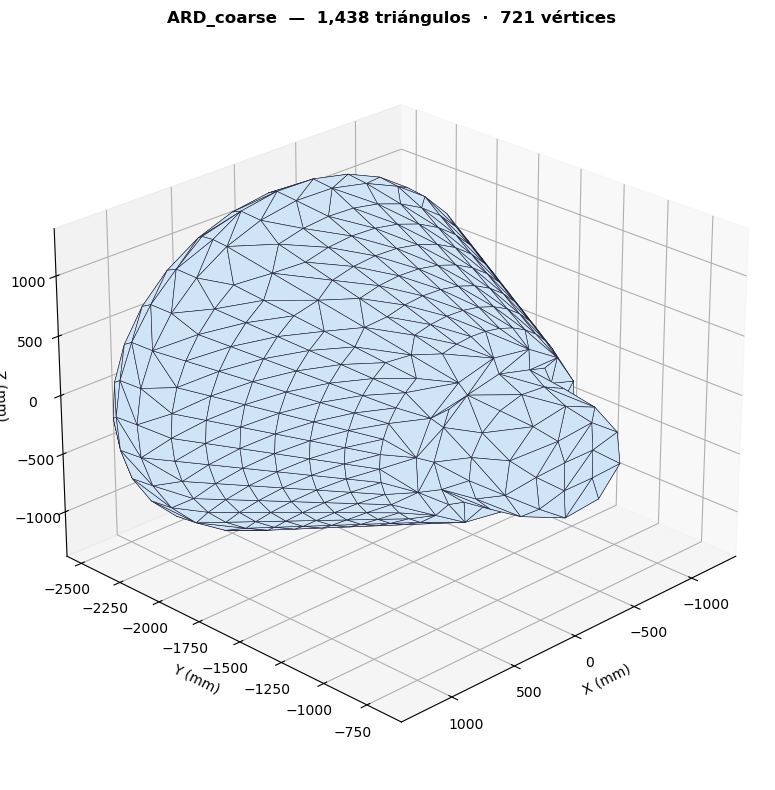

  Guardado: results\Plots\Mallados\ARD_coarsest.png


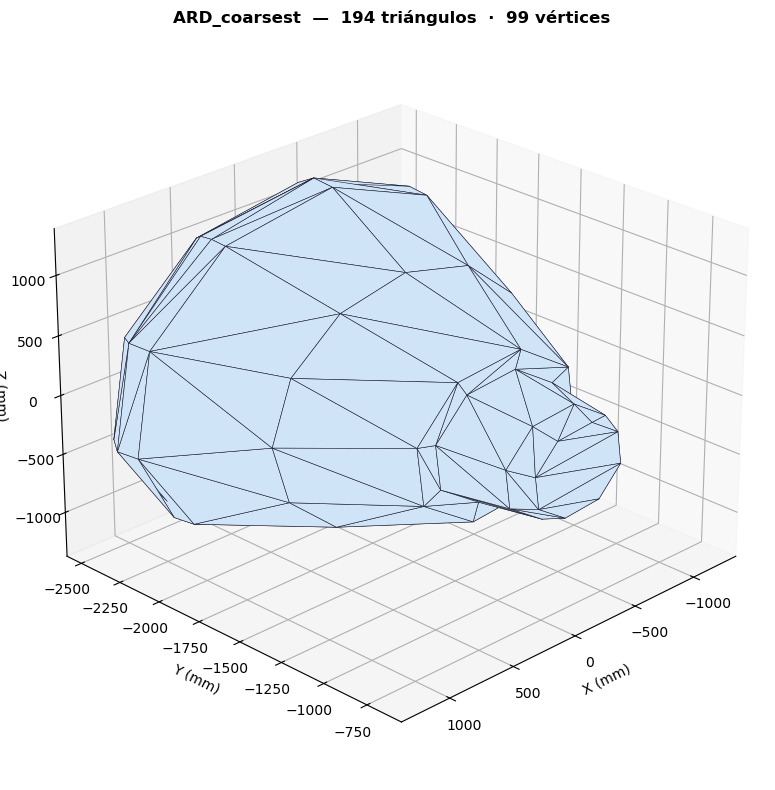

  Guardado: results\Plots\Mallados\ARD_fine.png


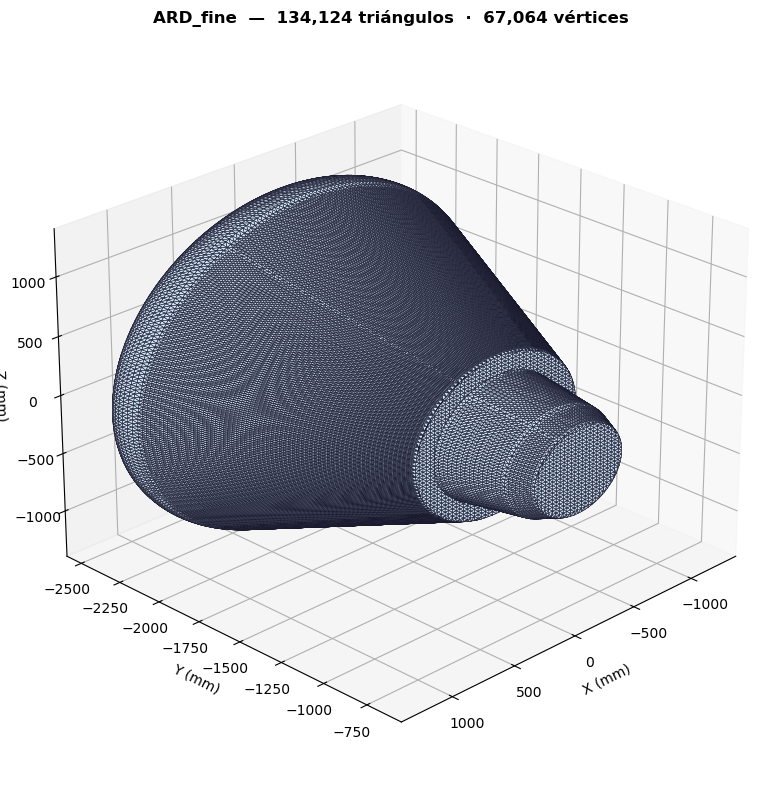

  Guardado: results\Plots\Mallados\ARD_ultrafine.png


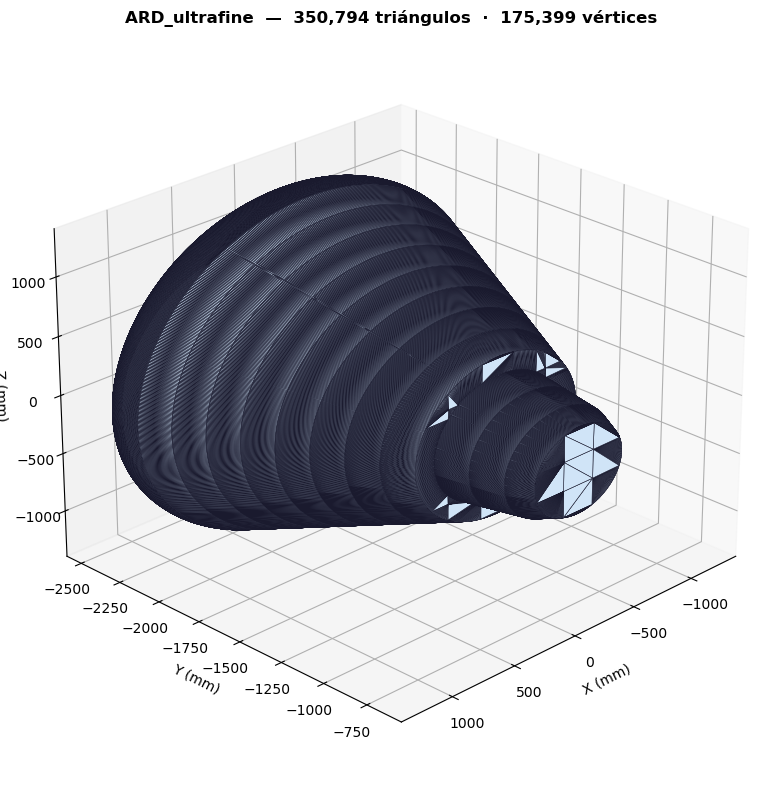

In [6]:
# Una figura por cada STL — guardadas en results/Plots/Mallados/
SAVE_DIR = Path("results/Plots/Mallados")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

for name, d in data.items():
    verts = d["verts"]; faces = d["faces"]
    bmin  = d["bmin"];  bmax  = d["bmax"]
    face_verts = verts[faces]

    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": "3d"})
    col = Poly3DCollection(
        face_verts,
        facecolor="#d0e4f7",
        edgecolor="#1a1a2e",
        linewidth=0.4,
        alpha=1.0,
    )
    ax.add_collection3d(col)
    ax.set_xlim(bmin[0], bmax[0])
    ax.set_ylim(bmin[1], bmax[1])
    ax.set_zlim(bmin[2], bmax[2])
    ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)"); ax.set_zlabel("Z (mm)")
    ax.set_title(f"{name}  —  {len(faces):,} triángulos  ·  {len(verts):,} vértices",
                 fontsize=12, fontweight="bold")
    ax.view_init(elev=25, azim=45)
    plt.tight_layout()
    out = SAVE_DIR / f"{name}.png"
    plt.savefig(out, dpi=150)
    print(f"  Guardado: {out}")
    plt.show()